<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite’

survey-results-publ 100%[===================>] 201.62M  4.61MB/s    in 47s     
2026-09-28 11:16:03 (4.26 MB/s) - ‘survey-results-public.sqlite’ saved [211415040/211415040]


#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 101.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 160.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]


In [3]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 153.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 151.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 161.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


In [10]:
!pip install seaborn

In [11]:
import seaborn as sns

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [5]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437

#### Demo 2: List All Tables


In [6]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [7]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568

## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


Original rows: 33740
Rows after removing outliers: 27864
Outliers removed: 5876

/tmp/ipykernel_300/4205261037.py:29: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_clean['CompTotal'], vert=False)

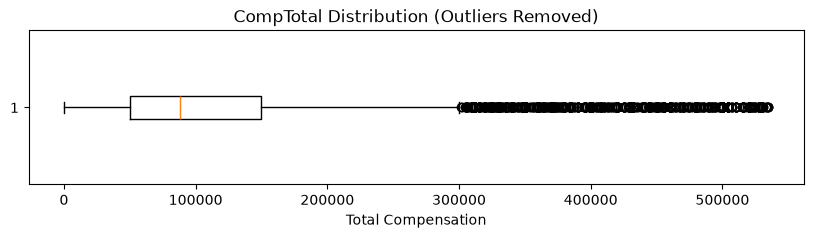

In [15]:
# Extract compensation values
QUERY = """
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL
"""
df = pd.read_sql_query(QUERY, conn)

# Calculate IQR
Q1 = df['CompTotal'].quantile(0.25)
Q3 = df['CompTotal'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df_clean = df[
(df['CompTotal'] >= lower_bound) &
(df['CompTotal'] <= upper_bound)
]

print(f"Original rows: {len(df)}")
print(f"Rows after removing outliers: {len(df_clean)}")
print(f"Outliers removed: {len(df) - len(df_clean)}")

# Box plot
plt.figure(figsize=(10, 2))
plt.boxplot(df_clean['CompTotal'], vert=False)
plt.title('CompTotal Distribution (Outliers Removed)')
plt.xlabel('Total Compensation')
plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


/tmp/ipykernel_300/3241006228.py:28: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df['AgeNumeric'], vert=False)

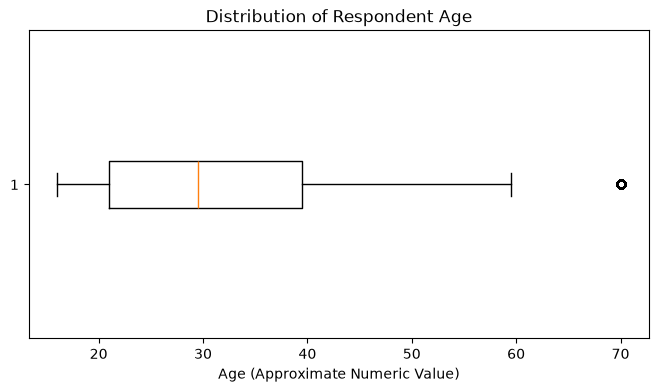

In [9]:
# Extract Age data
QUERY = """
SELECT Age
FROM main
WHERE Age IS NOT NULL
"""
df = pd.read_sql_query(QUERY, conn)

# Map age groups to approximate numeric values
age_mapping = {
'Under 18 years old': 16,
'18-24 years old': 21,
'25-34 years old': 29.5,
'35-44 years old': 39.5,
'45-54 years old': 49.5,
'55-64 years old': 59.5,
'65 years or older': 70,
'Prefer not to say': None
}

df['AgeNumeric'] = df['Age'].map(age_mapping)

# Remove unmapped values
df = df.dropna(subset=['AgeNumeric'])

# Create box plot
plt.figure(figsize=(8, 4))
plt.boxplot(df['AgeNumeric'], vert=False)
plt.title('Distribution of Respondent Age')
plt.xlabel('Age (Approximate Numeric Value)')
plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


<Figure size 1200x600 with 0 Axes>

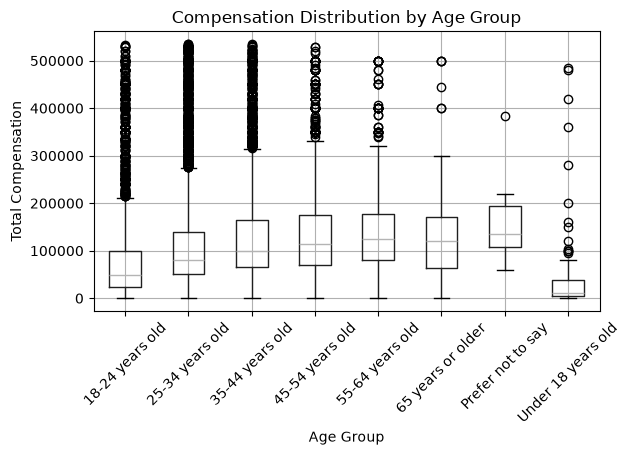

In [18]:
QUERY = """
SELECT Age, CompTotal
FROM main
WHERE Age IS NOT NULL
AND CompTotal IS NOT NULL
"""

df = pd.read_sql_query(QUERY, conn)

Q1 = df['CompTotal'].quantile(0.25)
Q3 = df['CompTotal'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[
(df['CompTotal'] >= lower_bound) &
(df['CompTotal'] <= upper_bound)
]

plt.figure(figsize=(12, 6))

df_clean.boxplot(
column='CompTotal',
by='Age',
rot=45
)

plt.title('Compensation Distribution by Age Group')
plt.suptitle('')
plt.xlabel('Age Group')
plt.ylabel('Total Compensation')

plt.tight_layout()
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


Original rows: 22478
Rows after removing outliers: 18459
Outliers removed: 4019

<Figure size 1200x600 with 0 Axes>

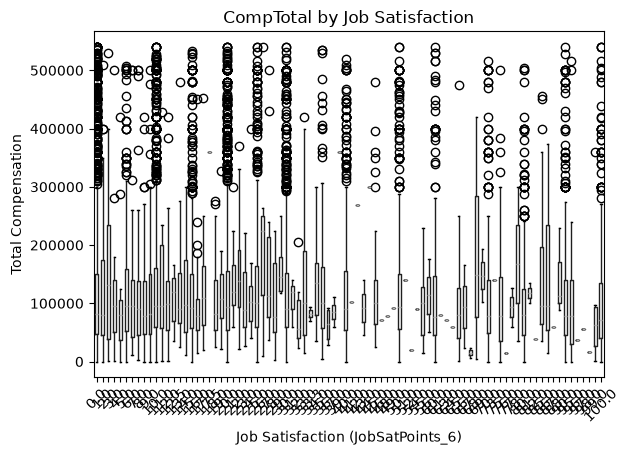

In [21]:
# Extract required columns
QUERY = """
SELECT CompTotal, JobSatPoints_6
FROM main
WHERE CompTotal IS NOT NULL
    AND JobSatPoints_6 IS NOT NULL
"""

df = pd.read_sql_query(QUERY, conn)

# Remove outliers using IQR
Q1 = df['CompTotal'].quantile(0.25)
Q3 = df['CompTotal'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[
    (df['CompTotal'] >= lower_bound) &
    (df['CompTotal'] <= upper_bound)
]

print("Original rows:", len(df))
print("Rows after removing outliers:", len(df_clean))
print("Outliers removed:", len(df) - len(df_clean))

# Box plot
plt.figure(figsize=(12, 6))

df_clean.boxplot(
    column='CompTotal',
    by='JobSatPoints_6',
    rot=45,
    grid=False
)

plt.title('CompTotal by Job Satisfaction')
plt.suptitle('')
plt.xlabel('Job Satisfaction (JobSatPoints_6)')
plt.ylabel('Total Compensation')

plt.tight_layout()
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


Rows before cleaning: 16326
Rows after cleaning: 15654
Outliers removed: 672

<Figure size 1200x600 with 0 Axes>

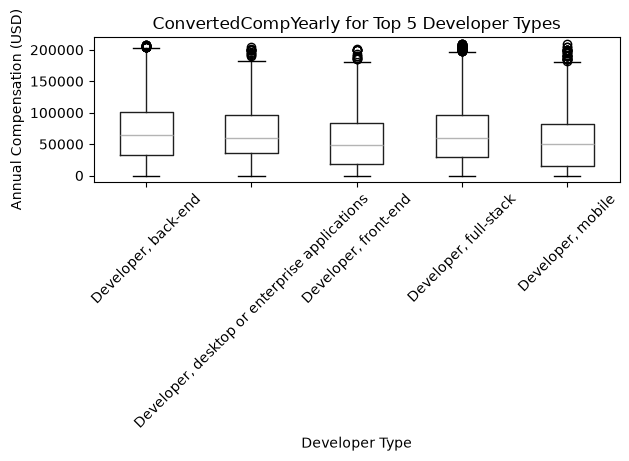

In [22]:
# Extract data
QUERY = """
SELECT DevType, ConvertedCompYearly
FROM main
WHERE DevType IS NOT NULL
AND ConvertedCompYearly IS NOT NULL
"""

df = pd.read_sql_query(QUERY, conn)

# Split multiple developer types into separate rows
df['DevType'] = df['DevType'].str.split(';')
df = df.explode('DevType')

# Find Top 5 developer types
top5_devtypes = df['DevType'].value_counts().head(5).index

# Keep only Top 5
df_top5 = df[df['DevType'].isin(top5_devtypes)]

# Remove outliers using IQR
Q1 = df_top5['ConvertedCompYearly'].quantile(0.25)
Q3 = df_top5['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df_top5[
    (df_top5['ConvertedCompYearly'] >= lower_bound) &
    (df_top5['ConvertedCompYearly'] <= upper_bound)
]

print("Rows before cleaning:", len(df_top5))
print("Rows after cleaning:", len(df_clean))
print("Outliers removed:", len(df_top5) - len(df_clean))

# Box plot
plt.figure(figsize=(12, 6))

df_clean.boxplot(
    column='ConvertedCompYearly',
    by='DevType',
    rot=45,
    grid=False
)

plt.title('ConvertedCompYearly for Top 5 Developer Types')
plt.suptitle('')
plt.xlabel('Developer Type')
plt.ylabel('Annual Compensation (USD)')

plt.tight_layout()
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


Top 5 Countries:
Country
United States of America                                7042
Germany                                                 3004
United Kingdom of Great Britain and Northern Ireland    2008
Ukraine                                                 1610
India                                                   1551
Name: count, dtype: int64

Original rows: 15215
Rows after removing outliers: 13292

<Figure size 1200x600 with 0 Axes>

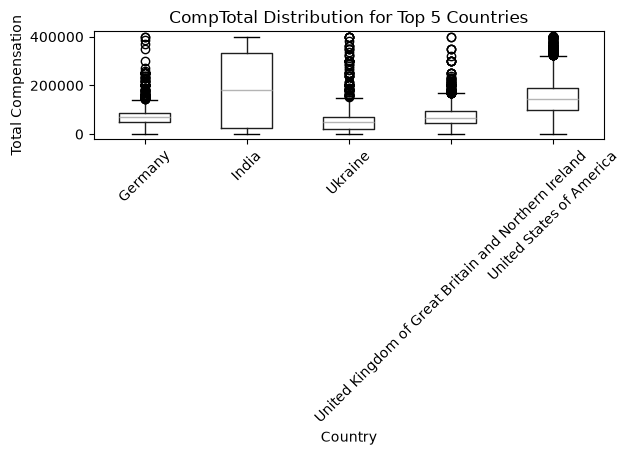

In [23]:
# Extract data
QUERY = """
SELECT Country, CompTotal
FROM main
WHERE Country IS NOT NULL
    AND CompTotal IS NOT NULL
"""

df = pd.read_sql_query(QUERY, conn)

# Get Top 5 countries by respondent count
top5_countries = df['Country'].value_counts().head(5).index

# Filter for Top 5 countries
df_top5 = df[df['Country'].isin(top5_countries)]

# Remove outliers using IQR
Q1 = df_top5['CompTotal'].quantile(0.25)
Q3 = df_top5['CompTotal'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df_top5[
    (df_top5['CompTotal'] >= lower_bound) &
    (df_top5['CompTotal'] <= upper_bound)
]

print("Top 5 Countries:")
print(df_top5['Country'].value_counts())

print(f"\nOriginal rows: {len(df_top5)}")
print(f"Rows after removing outliers: {len(df_clean)}")

# Create box plot
plt.figure(figsize=(12, 6))

df_clean.boxplot(
    column='CompTotal',
    by='Country',
    rot=45,
    grid=False
)

plt.title('CompTotal Distribution for Top 5 Countries')
plt.suptitle('')
plt.xlabel('Country')
plt.ylabel('Total Compensation')

plt.tight_layout()
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


Original rows: 33703
Rows after removing outliers: 27830

<Figure size 1600x800 with 0 Axes>

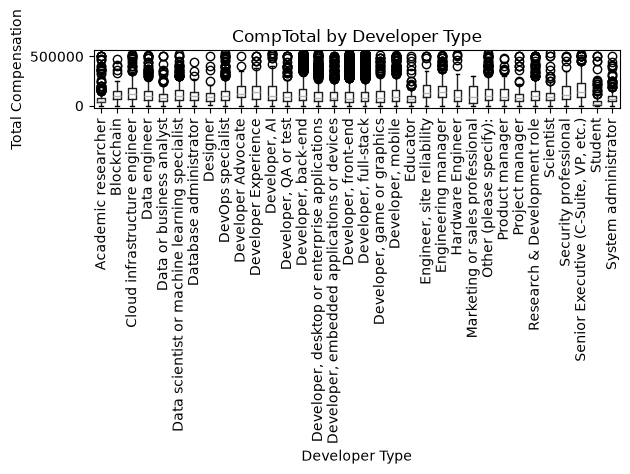

In [24]:
# Extract data
QUERY = """
SELECT DevType, CompTotal
FROM main
WHERE DevType IS NOT NULL
    AND CompTotal IS NOT NULL
"""

df = pd.read_sql_query(QUERY, conn)

# Split multiple DevType values into separate rows
df['DevType'] = df['DevType'].str.split(';')
df = df.explode('DevType')

# Remove leading/trailing spaces
df['DevType'] = df['DevType'].str.strip()

# Remove outliers using IQR
Q1 = df['CompTotal'].quantile(0.25)
Q3 = df['CompTotal'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[
    (df['CompTotal'] >= lower_bound) &
    (df['CompTotal'] <= upper_bound)
]

print(f"Original rows: {len(df)}")
print(f"Rows after removing outliers: {len(df_clean)}")

# Box plot
plt.figure(figsize=(16, 8))

df_clean.boxplot(
    column='CompTotal',
    by='DevType',
    rot=90,
    grid=False
)

plt.title('CompTotal by Developer Type')
plt.suptitle('')
plt.xlabel('Developer Type')
plt.ylabel('Total Compensation')

plt.tight_layout()
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


Original rows: 27797
Rows after removing outliers: 27027
Outliers removed: 770

<Figure size 1200x600 with 0 Axes>

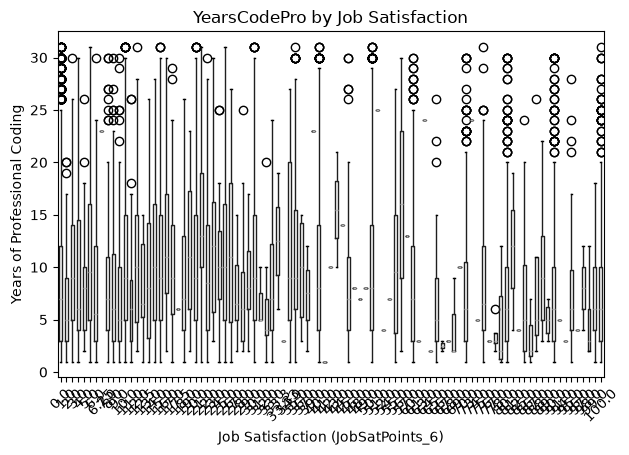

In [25]:
# Extract data
QUERY = """
SELECT YearsCodePro, JobSatPoints_6
FROM main
WHERE YearsCodePro IS NOT NULL
    AND JobSatPoints_6 IS NOT NULL
"""

df = pd.read_sql_query(QUERY, conn)

# Convert YearsCodePro to numeric
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

# Remove any rows that couldn't be converted
df = df.dropna(subset=['YearsCodePro'])

# Remove outliers using IQR
Q1 = df['YearsCodePro'].quantile(0.25)
Q3 = df['YearsCodePro'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[
    (df['YearsCodePro'] >= lower_bound) &
    (df['YearsCodePro'] <= upper_bound)
]

print(f"Original rows: {len(df)}")
print(f"Rows after removing outliers: {len(df_clean)}")
print(f"Outliers removed: {len(df) - len(df_clean)}")

# Box plot
plt.figure(figsize=(12, 6))

df_clean.boxplot(
    column='YearsCodePro',
    by='JobSatPoints_6',
    rot=45,
    grid=False
)

plt.title('YearsCodePro by Job Satisfaction')
plt.suptitle('')
plt.xlabel('Job Satisfaction (JobSatPoints_6)')
plt.ylabel('Years of Professional Coding')

plt.tight_layout()
plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [26]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
